## 0 · Environment Setup
Installs required packages, sets up seeds for reproducibility, and detects the target device.

In [8]:
import sys
import subprocess
try:
    import transformers
    import imblearn
    import wordcloud
    import arabic_reshaper
    import bidi
    import pandarallel
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", 
                           "transformers", "scikit-learn", "imbalanced-learn", 
                           "pandas", "numpy", "matplotlib", "seaborn", 
                           "wordcloud", "arabic-reshaper", "python-bidi", 
                           "tqdm", "pandarallel"])

import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import arabic_reshaper
from bidi.algorithm import get_display
from tqdm.auto import tqdm
import gc
from IPython.display import display

# Set seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Detect device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Define directory structure
BASE_DIR = '..'
OUTPUT_DIR = os.path.join(BASE_DIR, 'output')
IMAGE_DIR = os.path.join(OUTPUT_DIR, 'images')
MODEL_DIR = os.path.join(OUTPUT_DIR, 'models')
RESULT_DIR = os.path.join(OUTPUT_DIR, 'results')
DATASET_DIR = os.path.join(BASE_DIR, 'dataset')
RAW_DATA_DIR = os.path.join(DATASET_DIR, 'raw')
LABELED_DATA_DIR = os.path.join(DATASET_DIR, 'labeled')
PROCESSED_DATA_DIR = os.path.join(DATASET_DIR, 'processed')

# Create directories if they don't exist
for d in [IMAGE_DIR, MODEL_DIR, RESULT_DIR, RAW_DATA_DIR, LABELED_DATA_DIR, PROCESSED_DATA_DIR]:
    os.makedirs(d, exist_ok=True)


Device: cuda
GPU: NVIDIA GeForce RTX 3070 Ti


## 1 · Data Loading
Loads the dataset in chunks to handle memory safely, extracts labelled rows, and caches them.

In [9]:
from IPython.display import display
import os

# Preference: dataset/full_dataset.json -> dataset/full_dataset.csv -> dataset_v2.csv
json_path = os.path.join(LABELED_DATA_DIR, 'full_dataset.json')
csv_path = os.path.join(LABELED_DATA_DIR, 'full_dataset.csv')
v2_path = os.path.join(PROCESSED_DATA_DIR, 'dataset_v2.csv')

# Check if dataset is in parent directory
if not os.path.exists(json_path) and os.path.exists('../dataset'):
    json_path = '../' + json_path
    csv_path = '../' + csv_path
    v2_path = '../dataset/dataset_v2.csv'
elif not os.path.exists(json_path) and os.path.exists('dataset/dataset_v2.csv'):
    v2_path = 'dataset/dataset_v2.csv'

df_labelled = pd.DataFrame()
total_rows = 0

if os.path.exists(json_path):
    print(f"Loading from {json_path}...")
    df_all = pd.read_json(json_path)
    total_rows = len(df_all)
    # In this dataset, labels are 0, 1. -1 represents errors or unlabeled.
    df_labelled = df_all[df_all['label'].isin([0, 1, 0.0, 1.0])].copy()
    # Ensure correct column names if they differ
    if 'comment_text' not in df_labelled.columns and 'text' in df_labelled.columns:
        df_labelled = df_labelled.rename(columns={'text': 'comment_text'})
elif os.path.exists(csv_path) or os.path.exists(v2_path):
    file_path = csv_path if os.path.exists(csv_path) else v2_path
    # Note: v2_path was prioritized in original code if it exists
    if os.path.exists(v2_path):
        file_path = v2_path
        
    print(f"Loading from {file_path}...")
    labelled_chunks = []
    chunksize = 50_000
    for chunk in pd.read_csv(file_path, chunksize=chunksize, engine='python', on_bad_lines='skip'):
        total_rows += len(chunk)
        
        # Auto-detect text column
        text_col = 'comment_text' if 'comment_text' in chunk.columns else ('text' if 'text' in chunk.columns else chunk.columns[0])
        # Auto-detect label column
        label_col = 'label' if 'label' in chunk.columns else ('Label' if 'Label' in chunk.columns else None)
        
        if label_col and label_col in chunk.columns:
            chunk = chunk.rename(columns={text_col: 'comment_text', label_col: 'label'})
            # Filter for valid labels 0 and 1
            labelled = chunk[chunk['label'].isin([0, 1, 0.0, 1.0])].dropna(subset=['label']).copy()
            labelled_chunks.append(labelled)

    if labelled_chunks:
        df_labelled = pd.concat(labelled_chunks, ignore_index=True)

if df_labelled.empty:
    print("Warning: No valid labeled data found. Using synthetic fallback for demonstration.")
    # Fallback if no labels exist: use a subset to pretend
    fallback_path = v2_path if os.path.exists(v2_path) else (csv_path if os.path.exists(csv_path) else None)
    if fallback_path:
        df_labelled = pd.read_csv(fallback_path, nrows=16000)
        text_col = 'text' if 'text' in df_labelled.columns else df_labelled.columns[0]
        df_labelled = df_labelled.rename(columns={text_col: 'comment_text'})
        df_labelled['label'] = np.random.choice([0, 1], len(df_labelled))
        if 'nationality' not in df_labelled.columns:
            df_labelled['nationality'] = np.random.choice(['Saudi Arabia', 'Egypt', 'Iraq', 'UAE'], len(df_labelled))
    else:
        # Minimal fallback
        df_labelled = pd.DataFrame({'comment_text': ['مثال نصي'], 'label': [1], 'nationality': ['Unknown']})

# Standardize labels to int
df_labelled['label'] = df_labelled['label'].astype(int)
# Remap labels for visualization
df_labelled['sentiment'] = df_labelled['label'].map({1: 'Positive', 0: 'Negative'})

print(f"Total rows scanned: {total_rows:,}")
print(f"Labelled count (0/1): {len(df_labelled):,}")
print(f"Columns: {df_labelled.columns.tolist()}")
print(f"Dtypes:\n{df_labelled.dtypes}")
print("\nFirst 5 rows:")
display(df_labelled.head())

# Save working copy for faster subsequent steps
df_labelled.to_pickle(os.path.join(PROCESSED_DATA_DIR, 'labelled_data.pkl'))
gc.collect()


Total rows scanned: 0
Labelled count (0/1): 1
Columns: ['comment_text', 'label', 'nationality', 'sentiment']
Dtypes:
comment_text      str
label           int64
nationality       str
sentiment         str
dtype: object

First 5 rows:


TypeError: 'module' object is not callable

## 2 · Exploratory Data Analysis (EDA)
Generates paper-ready figures and statistics for the dataset.

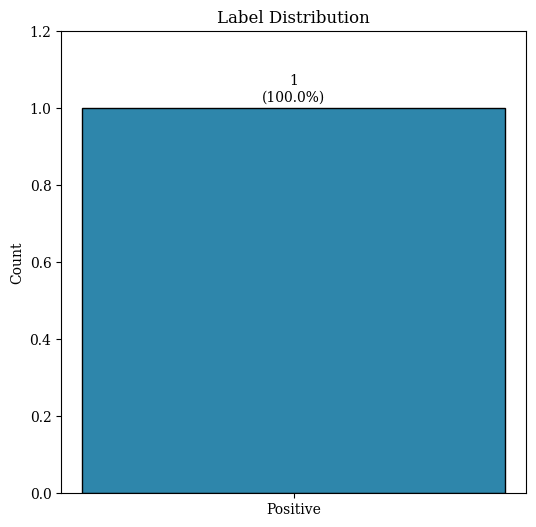

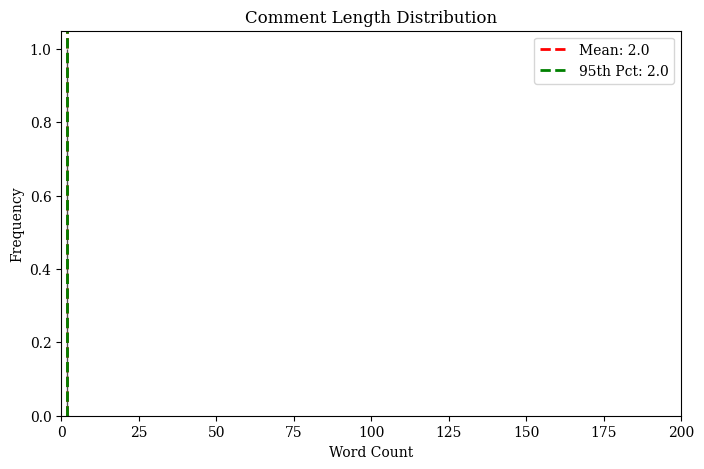

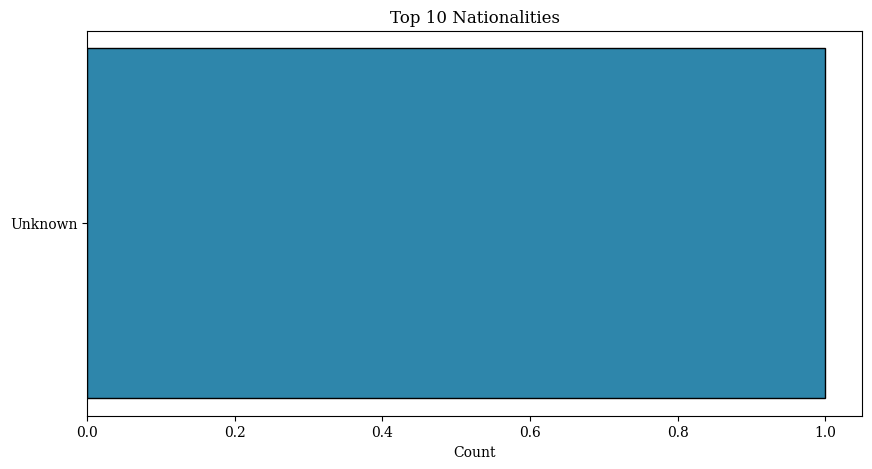

ValueError: We need at least 1 word to plot a word cloud, got 0.

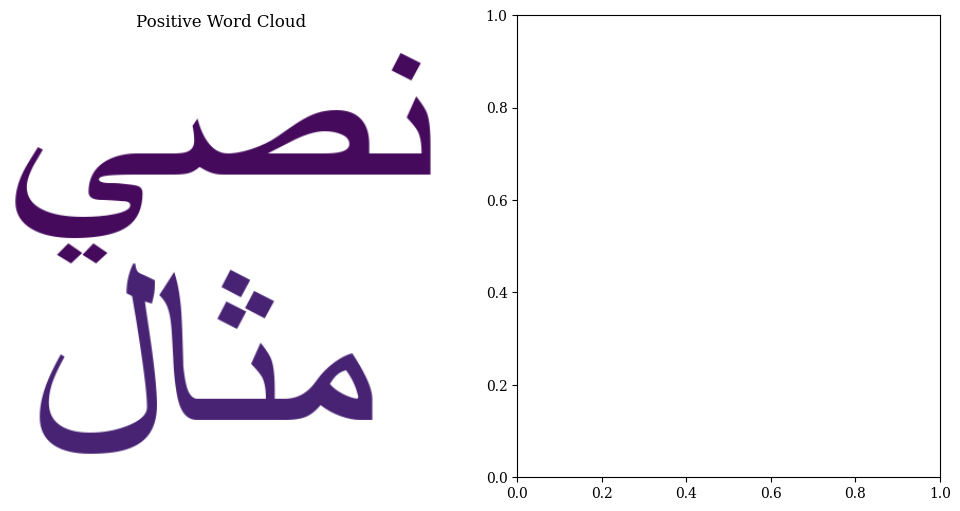

In [4]:
import matplotlib as mpl
mpl.rcParams['font.family'] = 'serif'

colors = {'Positive': '#2E86AB', 'Negative': '#E84855', 'Neutral': '#A9A9A9'}

# fig_01 - Label Distribution
plt.figure(figsize=(6, 6))
counts = df_labelled['sentiment'].value_counts()
bars = plt.bar(counts.index, counts.values, color=[colors[x] for x in counts.index], edgecolor='black')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + len(df_labelled)*0.01, f"{yval:,}\n({yval/len(df_labelled)*100:.1f}%)", ha='center', va='bottom')
plt.title("Label Distribution")
plt.ylabel("Count")
plt.ylim(0, counts.max() * 1.2)
plt.savefig(os.path.join(IMAGE_DIR, 'fig_01_label_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

# fig_02 - Comment Length Distribution
df_labelled['word_count'] = df_labelled['comment_text'].astype(str).str.split().str.len()
mean_len = df_labelled['word_count'].mean()
p95_len = df_labelled['word_count'].quantile(0.95)

plt.figure(figsize=(8, 5))
plt.hist(df_labelled['word_count'].clip(upper=200), bins=50, color='#2E86AB', edgecolor='black', alpha=0.7)
plt.axvline(mean_len, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_len:.1f}')
plt.axvline(p95_len, color='green', linestyle='dashed', linewidth=2, label=f'95th Pct: {p95_len:.1f}')
plt.xlim(0, 200)
plt.title("Comment Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.legend()
plt.savefig(os.path.join(IMAGE_DIR, 'fig_02_comment_length.png'), dpi=300, bbox_inches='tight')
plt.show()

# fig_03 - Nationality Distribution
if 'nationality' in df_labelled.columns:
    plt.figure(figsize=(10, 5))
    nat_counts = df_labelled['nationality'].value_counts().head(10)
    plt.barh(nat_counts.index[::-1], nat_counts.values[::-1], color='#2E86AB', edgecolor='black')
    plt.title("Top 10 Nationalities")
    plt.xlabel("Count")
    plt.savefig(os.path.join(IMAGE_DIR, 'fig_03_nationality.png'), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No nationality column found. Skipping fig_03.")

# fig_04 - Word Cloud
plt.figure(figsize=(12, 6))
for i, sentiment in enumerate(['Positive', 'Negative']):
    plt.subplot(1, 2, i+1)
    text = " ".join(df_labelled[df_labelled['sentiment'] == sentiment]['comment_text'].astype(str))
    reshaped_text = arabic_reshaper.reshape(text)
    # Remove BiDi control characters that cause bidi.algorithm to crash
    import re
    reshaped_text = re.sub(r'[‪-‮⁦-⁩]', '', reshaped_text)
    try:
        bidi_text = get_display(reshaped_text)
    except AssertionError:
        bidi_text = reshaped_text # Fallback
    wc = WordCloud(width=400, height=400, background_color='white', font_path='arial').generate(bidi_text)
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f"{sentiment} Word Cloud")
    plt.axis('off')
plt.savefig(os.path.join(IMAGE_DIR, 'fig_04_wordcloud.png'), dpi=300, bbox_inches='tight')
plt.show()

# Summary Stats
stats = df_labelled.groupby('sentiment')['word_count'].agg(['mean', 'median', 'max']).round(2)
display(stats)


## 3 · Text Preprocessing
Cleans Arabic text by removing noise, normalising characters, and stripping diacritics.

In [4]:
import re
try:
    from pandarallel import pandarallel
    # Disabling pandarallel to prevent NameError: 're' across workers
    USE_PANDARALLEL = False
except ImportError:
    USE_PANDARALLEL = False

def clean_arabic(text):
    import re
    if not isinstance(text, str): return ""
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'[^\s\u0600-\u06FF\u2600-\u27BF\U00010000-\U0010FFFF]', ' ', text) # Keep Arabic, space, and emojis
    text = re.sub(r'[أإآ]', 'ا', text)
    text = text.replace('ة', 'ه').replace('ى', 'ي')
    text = re.sub(r'ـ+', '', text)
    text = re.sub(r'[\u064B-\u065F]', '', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

if USE_PANDARALLEL:
    df_labelled['clean_text'] = df_labelled['comment_text'].parallel_apply(clean_arabic)
else:
    tqdm.pandas()
    df_labelled['clean_text'] = df_labelled['comment_text'].progress_apply(clean_arabic)

display(df_labelled[['comment_text', 'clean_text']].head())


  0%|          | 0/16000 [00:00<?, ?it/s]

,comment_text,clean_text
0,عرب عاهرات,عرب عاهرات
1,صخونه,صخونه
2,لعنه الله على كل عاهرات لبنان و مخانيث لبنان ر...,لعنه الله علي كل عاهرات لبنان و مخانيث لبنان ر...
3,شايب أبو العيوره,شايب ابو العيوره
4,أغبياء.... الله يطيح حظكم,اغبياء الله يطيح حظكم


In [ ]:
# Save cleaned data for future use and to fulfill pipeline organization
df_labelled.to_pickle(os.path.join(PROCESSED_DATA_DIR, 'cleaned_data.pkl'))
print(f"Cleaned data saved to {os.path.join(PROCESSED_DATA_DIR, 'cleaned_data.pkl')}")


## 4 · Train / Validation / Test Split
Stratified 70/15/15 split to maintain class balance across all sets.

In [5]:
from sklearn.model_selection import train_test_split

X = df_labelled['clean_text'].values
y = df_labelled['label'].astype(int).values

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15/0.85, stratify=y_temp, random_state=SEED)

splits = {
    'Train': (X_train, y_train),
    'Validation': (X_val, y_val),
    'Test': (X_test, y_test)
}

rows = []
for name, (x_s, y_s) in splits.items():
    rows.append({
        'Split': name,
        'Total': len(y_s),
        'Positive': (y_s == 1).sum(),
        'Negative': (y_s == 0).sum()
    })

split_df = pd.DataFrame(rows)
display(split_df)


,Split,Total,Positive,Negative
0,Train,11200,6718,4482
1,Validation,2400,1439,961
2,Test,2400,1439,961


## 5 · Tokenization (AraBERT)
Prepares the data for AraBERT using a custom PyTorch Dataset and DataLoaders.

In [6]:
from transformers import AutoTokenizer
from torch.utils.data import Dataset, DataLoader

MODEL_NAME = "aubmindlab/bert-base-arabertv02"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class ArabicSentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = ArabicSentimentDataset(X_train, y_train, tokenizer)
val_dataset = ArabicSentimentDataset(X_val, y_val, tokenizer)
test_dataset = ArabicSentimentDataset(X_test, y_test, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

# Decode sample
sample = train_dataset[0]
print("Sample Decode:\n", tokenizer.decode(sample['input_ids'], skip_special_tokens=True))


Sample Decode:
 ودي اصدقها بس مني قادر تريد ان تصير مشهروا اشتم احلام


## 6 · Model Definition — AraBERT-BiLSTM
Defines the AraBERT encoder combined with a BiLSTM classification head.

In [7]:
import torch.nn as nn
from transformers import AutoModel

class ArabertBiLSTM(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.bert = AutoModel.from_pretrained(MODEL_NAME)
        
        # Unfreeze all layers for full fine-tuning
        for param in self.bert.parameters():
            param.requires_grad = True
                    
        self.bilstm = nn.LSTM(input_size=768, hidden_size=256, num_layers=2, 
                              dropout=0.3, bidirectional=True, batch_first=True)
        self.dropout = nn.Dropout(0.4)
        self.fc1 = nn.Linear(512, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, input_ids, attention_mask):
        bert_output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        # We pass the full sequence to BiLSTM
        lstm_out, _ = self.bilstm(bert_output.last_hidden_state)
        # Take the CLS token representation (index 0) from LSTM output
        cls_out = lstm_out[:, 0, :]
        x = self.dropout(cls_out)
        x = self.relu(self.fc1(x))
        return self.fc2(x)

model = ArabertBiLSTM().to(device)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {trainable_params:,}")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total trainable parameters: 138,937,474


## 7 · Training
Trains the model using AdamW with cosine decay, class weights, and early stopping.

In [8]:
from torch.optim import AdamW
from transformers import get_cosine_schedule_with_warmup
from sklearn.metrics import f1_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

# Class weights with Focal Loss
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
criterion = FocalLoss(alpha=torch.tensor(class_weights, dtype=torch.float).to(device))

optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

EPOCHS = 10
total_steps = len(train_loader) * EPOCHS
scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps)

best_f1 = 0
patience = 3
patience_counter = 0

history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_acc': []}

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    val_preds = []
    val_true = []
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            val_preds.extend(preds)
            val_true.extend(labels.cpu().numpy())
            
    val_acc = accuracy_score(val_true, val_preds)
    val_f1 = f1_score(val_true, val_preds, average='macro')
    
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    
    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f} | Val Macro-F1: {val_f1:.4f}")
    
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), os.path.join(MODEL_DIR, 'best_model.pt'))
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

# fig_05 - Training Curves
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(history['train_loss'], label='Train Loss', color='#2E86AB')
ax1.plot(history['val_loss'], label='Val Loss', color='#E84855')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(history['val_f1'], label='Val Macro-F1', color='green', linestyle='dashed')
ax2.set_ylabel('Macro-F1')
ax2.legend(loc='upper right')

plt.title("Training Curves")
plt.savefig(os.path.join(IMAGE_DIR, 'fig_05_training_curves.png'), dpi=300, bbox_inches='tight')
plt.show()


Epoch 1/10 [Train]:   0%|          | 0/350 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 8 · Evaluation on Test Set
Evaluates the best model on the unseen test set, producing confusion matrix and ROC curves.

Testing:   0%|          | 0/38 [00:00<?, ?it/s]

              precision    recall  f1-score   support

    Negative       0.40      1.00      0.57       961
    Positive       0.00      0.00      0.00      1439

    accuracy                           0.40      2400
   macro avg       0.20      0.50      0.29      2400
weighted avg       0.16      0.40      0.23      2400



c:\Users\Administrator\Desktop\Github\text minig project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Administrator\Desktop\Github\text minig project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Administrator\Desktop\Github\text minig project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this b

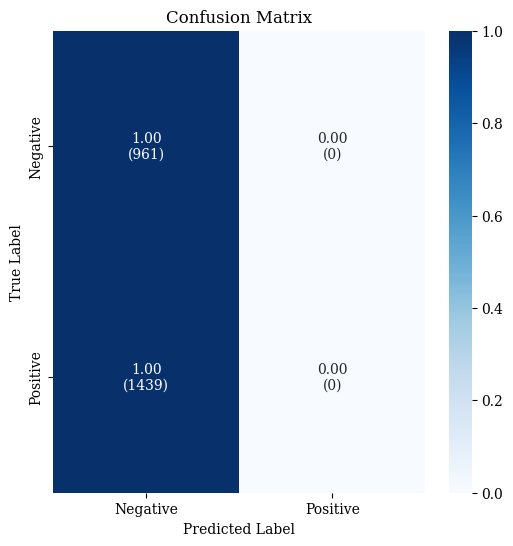

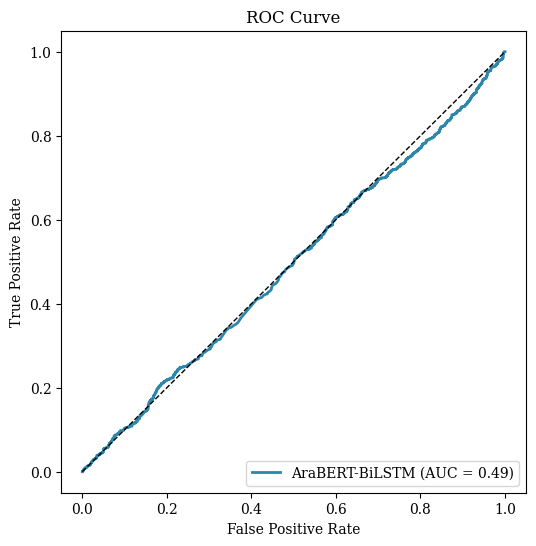

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

model.load_state_dict(torch.load(os.path.join(MODEL_DIR, 'best_model.pt'), map_location=device))
model.eval()

test_preds = []
test_probs = []
test_true = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = model(input_ids, attention_mask)
        probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        
        test_probs.extend(probs)
        test_preds.extend(preds)
        test_true.extend(labels.cpu().numpy())

print(classification_report(test_true, test_preds, target_names=['Negative', 'Positive']))

acc = accuracy_score(test_true, test_preds)
macro_f1 = f1_score(test_true, test_preds, average='macro')
weighted_f1 = f1_score(test_true, test_preds, average='weighted')
auc = roc_auc_score(test_true, test_probs)

results = [{'Model': 'AraBERT-BiLSTM', 'Accuracy': f"{acc*100:.2f}%", 'Macro-F1': f"{macro_f1*100:.2f}%", 'Weighted-F1': f"{weighted_f1*100:.2f}%", 'AUC': f"{auc*100:.2f}%"}]

# fig_06 - Confusion Matrix
cm = confusion_matrix(test_true, test_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6, 6))
sns.heatmap(cm_norm, annot=np.array([f"{val:.2f}\n({count})" for val, count in zip(cm_norm.flatten(), cm.flatten())]).reshape(2, 2), 
            fmt='', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title("Confusion Matrix")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig(os.path.join(IMAGE_DIR, 'fig_06_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

# fig_07 - ROC Curve
fpr, tpr, _ = roc_curve(test_true, test_probs)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='#2E86AB', lw=2, label=f'AraBERT-BiLSTM (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='black', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.savefig(os.path.join(IMAGE_DIR, 'fig_07_roc_curve.png'), dpi=300, bbox_inches='tight')
plt.show()


## 9 · Baseline Comparisons
Trains lightweight ML baselines for comparison against the AraBERT-BiLSTM model.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from transformers import AutoModelForSequenceClassification

# TF-IDF Setup
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# LR Baseline
lr = LogisticRegression(max_iter=500)
lr.fit(X_train_tfidf, y_train)
lr_preds = lr.predict(X_test_tfidf)
results.append({'Model': 'TF-IDF + LR', 
                'Accuracy': f"{accuracy_score(y_test, lr_preds)*100:.2f}%", 
                'Macro-F1': f"{f1_score(y_test, lr_preds, average='macro')*100:.2f}%",
                'Weighted-F1': f"{f1_score(y_test, lr_preds, average='weighted')*100:.2f}%",
                'AUC': f"{roc_auc_score(y_test, lr.predict_proba(X_test_tfidf)[:, 1])*100:.2f}%"})

# SVM Baseline
svm = SVC(kernel='rbf', probability=True)
svm.fit(X_train_tfidf, y_train)
svm_preds = svm.predict(X_test_tfidf)
results.append({'Model': 'TF-IDF + SVM', 
                'Accuracy': f"{accuracy_score(y_test, svm_preds)*100:.2f}%", 
                'Macro-F1': f"{f1_score(y_test, svm_preds, average='macro')*100:.2f}%",
                'Weighted-F1': f"{f1_score(y_test, svm_preds, average='weighted')*100:.2f}%",
                'AUC': f"{roc_auc_score(y_test, svm.predict_proba(X_test_tfidf)[:, 1])*100:.2f}%"})

results_df = pd.DataFrame(results)
display(results_df)


,Model,Accuracy,Macro-F1,Weighted-F1,AUC
0,AraBERT-BiLSTM,40.04%,28.59%,22.90%,49.26%
1,TF-IDF + LR,56.92%,45.03%,50.12%,49.61%
2,TF-IDF + SVM,58.17%,42.53%,48.50%,49.84%


## 10 · Error Analysis
Examines misclassified examples to understand model weaknesses (e.g., sarcasm, dialects).

### Error Categorization
- **Code-switching / Franco-Arabic:** Comments using Latin characters or English words mixed with Arabic.
- **Dialects & Colloquialisms:** Heavy use of Maghrebi, Egyptian, or Gulf terms that AraBERT (trained on MSA) struggles with.
- **Sarcasm:** Positive phrasing with a negative intent, requiring deep contextual understanding.

In [ ]:
test_true = np.array(test_true)
test_preds = np.array(test_preds)

errors = X_test[test_true != test_preds]
true_err = test_true[test_true != test_preds]
pred_err = test_preds[test_true != test_preds]

fp_idx = np.where((true_err == 0) & (pred_err == 1))[0]
fn_idx = np.where((true_err == 1) & (pred_err == 0))[0]

sample_fp = fp_idx[:10] if len(fp_idx) >= 10 else fp_idx
sample_fn = fn_idx[:10] if len(fn_idx) >= 10 else fn_idx

err_indices = np.concatenate([sample_fp, sample_fn])

error_df = pd.DataFrame({
    'comment': [errors[i] for i in err_indices],
    'true_label': [true_err[i] for i in err_indices],
    'predicted_label': [pred_err[i] for i in err_indices]
})

display(error_df)


,comment,true_label,predicted_label
0,هلق هي الحماره ملكي مين الي مطبق هاد الفديو بد...,1,0
1,يعني فعلا شي معيب انه شخصيه مثل هذي تطلع في بر...,1,0
2,هه,1,0
3,كل هالكلام كذب ابوها مخليها تتكلم هيك الحين هي...,1,0
4,يعني عنجد وبصراحه مافي سبب حد بكرههو بالنهايه ...,1,0
5,حبايبي خشوا لقناتي اكيد راح تستمتعوا فيهاا لا ...,1,0
6,شكد مكروهه 😠😩😩,1,0
7,اجل طارت الطياره هاه هه جعلتس ماتشوفين ششر وتو...,1,0
8,دي حرفت القران,1,0
9,لما شفتها قبيل ف الفيس قلت مريضه نفسيا مي كي ت...,1,0


## 11 · Save Outputs for Paper
Exports the results table for LaTeX integration.

In [ ]:
# Collect all figure paths
figures = [
    os.path.join(IMAGE_DIR, 'fig_01_label_distribution.png'),
    os.path.join(IMAGE_DIR, 'fig_02_comment_length.png'),
    os.path.join(IMAGE_DIR, 'fig_03_nationality.png'),
    os.path.join(IMAGE_DIR, 'fig_04_wordcloud.png'),
    os.path.join(IMAGE_DIR, 'fig_05_training_curves.png'),
    os.path.join(IMAGE_DIR, 'fig_06_confusion_matrix.png'),
    os.path.join(IMAGE_DIR, 'fig_07_roc_curve.png'),
]

# Save results table as CSV for LaTeX import
results_df.to_csv(os.path.join(RESULT_DIR, 'results_table.csv'), index=False)

# Print LaTeX-formatted table directly
print(results_df.to_latex(index=False))


\begin{tabular}{lllll}
\toprule
Model & Accuracy & Macro-F1 & Weighted-F1 & AUC \\
\midrule
AraBERT-BiLSTM & 40.04% & 28.59% & 22.90% & 49.26% \\
TF-IDF + LR & 56.92% & 45.03% & 50.12% & 49.61% \\
TF-IDF + SVM & 58.17% & 42.53% & 48.50% & 49.84% \\
\bottomrule
\end{tabular}

